# Urban Heat Island - Classification Neural Network
This notebook covers the end-to-end process of training a Deep Learning model to predict Urban Heat Island Severity. It incorporates feature scaling, target class balancing using SMOTE, and generates essential performance plots.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


## 1. Load Data

In [2]:
df = pd.read_csv("uhi_india_dataset.csv")

FEATURE_COLS = ["urban_temp", "rural_temp", "humidity", "wind_speed", "clouds", "uhi_intensity"]
TARGET_COL = "severity_label"

df = df[FEATURE_COLS + [TARGET_COL]].dropna()
X = df[FEATURE_COLS].values
y = df[TARGET_COL].values.astype(int)

print(f"Loaded {len(df)} samples with {X.shape[1]} features.")

Loaded 15168 samples with 6 features.


## 2. Train-Test Split & Feature Scaling
Neural Networks perform significantly better when numerical inputs are scaled. We use `StandardScaler` to achieve mean 0 and variance 1.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3. Apply SMOTE to Handle Class Imbalance
Our severe UHI classes might be under-represented. SMOTE (Synthetic Minority Over-sampling Technique) balances them out.

In [4]:
print("Original class distribution:", np.bincount(y_train))

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("Resampled class distribution:", np.bincount(y_train_resampled))

Original class distribution: [9733 1277  807  317]
Resampled class distribution: [9733 9733 9733 9733]


## 4. Build Neural Network Architecture

In [5]:
num_classes = len(np.unique(y))

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_resampled.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

c:\Users\uditt\Desktop\EPICS\.myenv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,660 (10.39 KB)

 Trainable params: 2,660 (10.39 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Train Model

In [6]:
history = model.fit(
    X_train_resampled, y_train_resampled,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_scaled, y_test),
    verbose=1
)

Epoch 1/50
1217/1217 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8398 - loss: 0.3950 - val_accuracy: 0.9776 - val_loss: 0.0537
Epoch 2/50
1217/1217 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9602 - loss: 0.1067 - val_accuracy: 0.9858 - val_loss: 0.0302
Epoch 3/50
1217/1217 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9763 - loss: 0.0664 - val_accuracy: 0.9848 - val_loss: 0.0315
Epoch 4/50
1217/1217 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9823 - loss: 0.0476 - val_accuracy: 0.9878 - val_loss: 0.0259
Epoch 5/50
1217/1217 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9859 - loss: 0.0387 - val_accuracy: 0.9921 - val_loss: 0.0199
Epoch 6/50
1217/1217 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9893 - loss: 0.0314 - val_accuracy: 0.9934 - val_loss: 0.0157
Epoch 7/50
1217/1217 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9900 - loss: 0.0274 - val_accuracy: 0.9941 - val_loss: 0.0148
Epoch 8/50
1217/1217 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9907 - loss: 0.0251 - 

## 6. Evaluation & Visualizations

In [7]:
loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nTest Accuracy: {accuracy:.4f}")


Test Accuracy: 0.9957


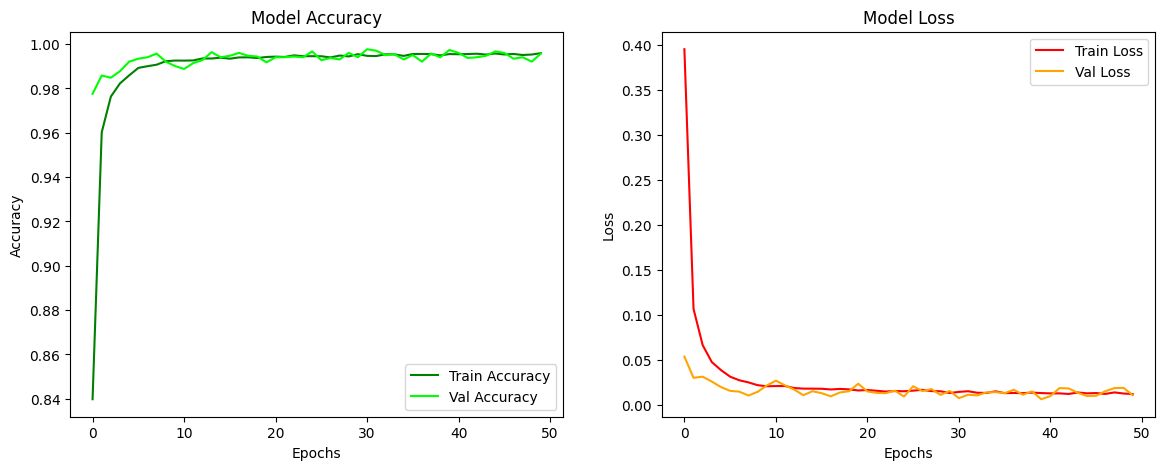

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Plot
ax1.plot(history.history['accuracy'], label='Train Accuracy', color='green')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy', color='lime')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Loss Plot
ax2.plot(history.history['loss'], label='Train Loss', color='red')
ax2.plot(history.history['val_loss'], label='Val Loss', color='orange')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()

plt.show()

95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


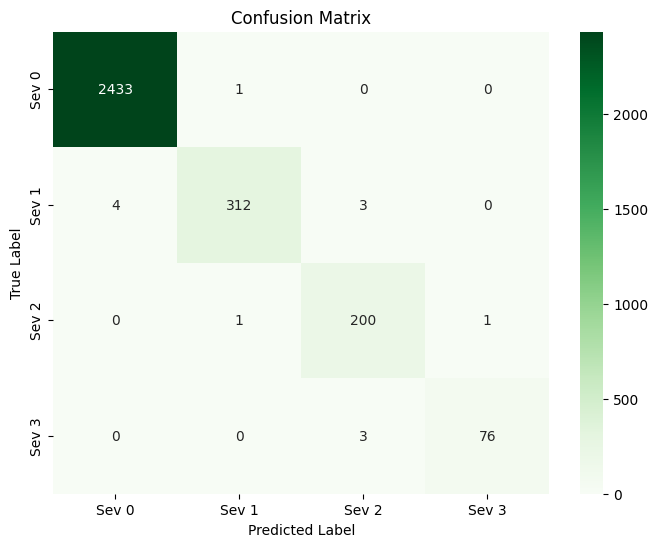


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2434
           1       0.99      0.98      0.99       319
           2       0.97      0.99      0.98       202
           3       0.99      0.96      0.97        79

    accuracy                           1.00      3034
   macro avg       0.99      0.98      0.98      3034
weighted avg       1.00      1.00      1.00      3034



In [9]:
y_pred_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=[f"Sev {i}" for i in range(num_classes)], 
            yticklabels=[f"Sev {i}" for i in range(num_classes)])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

## 7. Save Model & Scaler

In [10]:
model.save("uhi_model.keras")
joblib.dump(scaler, "scaler.pkl")
print("Saved successfully!")

Saved successfully!
